# Chapter 5 — Scoring Table Generator
Produces the real-data table for the thesis report showing how raw rating, review count,
Bayesian-adjusted rating, cosine similarity, and final score combine per place.

In [4]:
import ast
import json
import pickle
import warnings

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# ── Paths (relative to this notebook) ─────────────────────────────────────────
DATA_PATH       = '../../backend/data/cleaned_merged_data.csv'
CAT_MODEL_PATH  = '../../backend/model/categories_tfidf_model.pkl'
DESC_MODEL_PATH = '../../backend/model/description_tfidf_model.pkl'
WEIGHTS_PATH    = '../../backend/model/weights.json'

print('Loading data and models...')
df = pd.read_csv(DATA_PATH)

with open(CAT_MODEL_PATH, 'rb') as f:
    cat_model = pickle.load(f)
cat_vectorizer   = cat_model['vectorizer']
cat_tfidf_matrix = cat_model['tfidf_matrix']

with open(DESC_MODEL_PATH, 'rb') as f:
    desc_model = pickle.load(f)
desc_vectorizer   = desc_model['vectorizer']
desc_tfidf_matrix = desc_model['description_matrix']

try:
    with open(WEIGHTS_PATH) as f:
        w = json.load(f)
    RATING_WEIGHT = float(w.get('rating_weight', 0.4))
    REVIEW_WEIGHT = float(w.get('review_weight', 0.6))
    print('Loaded tuned weights from weights.json')
except FileNotFoundError:
    RATING_WEIGHT, REVIEW_WEIGHT = 0.4, 0.6
    print('weights.json not found — using defaults (rating=0.4, reviews=0.6)')

df['_rating']  = pd.to_numeric(df['rating'],      errors='coerce')
df['_reviews'] = pd.to_numeric(df['num_reviews'],  errors='coerce')

REVIEWS_MEDIAN  = df['_reviews'].median()
RATING_MEAN     = df['_rating'].mean()
RATING_FALLBACK = df['_rating'].median()

print(f'Dataset: {len(df):,} places')
print(f'Median reviews : {REVIEWS_MEDIAN:.0f}')
print(f'Mean rating    : {RATING_MEAN:.2f}')
print(f'Weights        : rating={RATING_WEIGHT}, reviews={REVIEW_WEIGHT}')

Loading data and models...
weights.json not found — using defaults (rating=0.4, reviews=0.6)
Dataset: 4,069 places
Median reviews : 33
Mean rating    : 3.70
Weights        : rating=0.4, reviews=0.6


## Step 1 — Define the scoring functions
Exact logic mirrored from `backend/api.py`.

In [5]:
def bayesian_rating(R, v, C=RATING_MEAN, m=REVIEWS_MEDIAN):
    """Bayesian average: pulls low-review places toward the global mean."""
    if pd.isna(R):
        R = RATING_FALLBACK
    if pd.isna(v):
        v = 0.0
    if (v + m) == 0:
        return C
    return (v / (v + m)) * R + (m / (v + m)) * C


def weighted_score(R, v):
    """Combines Bayesian rating with log-dampened review volume."""
    if pd.isna(R) and pd.isna(v):
        return 0.0
    b = bayesian_rating(R, v)
    v_safe = 0.0 if pd.isna(v) else v
    volume_bonus = np.log10(v_safe + 1) * REVIEW_WEIGHT
    return (b * RATING_WEIGHT) + volume_bonus


def get_similarities(category_key, query_str):
    """Returns (category_similarity, description_similarity) for a given query."""
    cat_vec  = cat_vectorizer.transform([category_key])
    desc_vec = desc_vectorizer.transform([query_str])
    cat_sims  = cosine_similarity(cat_vec,  cat_tfidf_matrix)[0]
    desc_sims = cosine_similarity(desc_vec, desc_tfidf_matrix)[0]
    return cat_sims, desc_sims


def final_score(ws, cat_sim, desc_sim):
    return ws + (cat_sim * 2.0) + (desc_sim * 1.5)


print('Scoring functions ready.')

Scoring functions ready.


## Step 2 — Pick a province + interest and compute scores
Change `PROVINCE` and `USER_INTERESTS` to explore different scenarios.

In [6]:
# ── Configuration ─────────────────────────────────────────────────────────────
PROVINCE       = 'Siem Reap'
USER_INTERESTS = ['temple', 'landmark_attraction', 'historical_monument']
TOP_N          = 20   # candidates to score before picking the display sample

# ── Filter province ────────────────────────────────────────────────────────────
prov_df = df[df['province'] == PROVINCE].copy()
print(f'{PROVINCE}: {len(prov_df)} places in dataset')

# ── Compute similarity vectors for the user query ─────────────────────────────
query_category = ' '.join(USER_INTERESTS)
query_desc     = query_category.replace('_', ' ')
cat_sims, desc_sims = get_similarities(query_category, query_desc)

# Assign similarity scores using original df indices
prov_df['cat_sim']  = cat_sims[prov_df.index]
prov_df['desc_sim'] = desc_sims[prov_df.index]

# ── Compute all scores ─────────────────────────────────────────────────────────
prov_df['raw_rating']       = prov_df['_rating']
prov_df['review_count']     = prov_df['_reviews']
prov_df['bayesian_rating']  = prov_df.apply(
    lambda r: bayesian_rating(r['_rating'], r['_reviews']), axis=1
)
prov_df['weighted_score']   = prov_df.apply(
    lambda r: weighted_score(r['_rating'], r['_reviews']), axis=1
)
prov_df['final_score']      = prov_df.apply(
    lambda r: final_score(r['weighted_score'], r['cat_sim'], r['desc_sim']), axis=1
)

# ── Filter to relevant ontology categories ─────────────────────────────────────
relevant = prov_df[prov_df['ontologyId'].isin(USER_INTERESTS)].copy()
if relevant.empty:
    relevant = prov_df.copy()   # fallback: show all if no exact match

relevant = relevant.sort_values('final_score', ascending=False)
print(f'Relevant candidates: {len(relevant)}')

Siem Reap: 1023 places in dataset
Relevant candidates: 213


## Step 3 — Build the thesis table
Hand-pick a diverse sample: high-review landmark, low-review gem, missing rating, mid-tier, top scorer.

In [7]:
COLS = ['title', 'ontologyId', 'raw_rating', 'review_count',
        'bayesian_rating', 'cat_sim', 'desc_sim', 'weighted_score', 'final_score']

def pick_diverse_sample(df_sorted, n=5):
    """Select places that illustrate different score patterns for the thesis table."""
    candidates = df_sorted[COLS].dropna(subset=['title'])

    # 1. Highest final score
    top = candidates.head(1)

    # 2. High review count (popular landmark)
    high_reviews = candidates[candidates['review_count'] > REVIEWS_MEDIAN * 2].head(1)

    # 3. Low review count but decent rating (hidden gem candidate)
    low_reviews = candidates[
        (candidates['review_count'] < REVIEWS_MEDIAN * 0.3) &
        (candidates['raw_rating'] >= 4.0)
    ].head(1)

    # 4. Missing rating (shows Bayesian fallback)
    no_rating = candidates[candidates['raw_rating'].isna()].head(1)

    # 5. Mid-range place
    mid_idx = len(candidates) // 2
    mid = candidates.iloc[mid_idx:mid_idx+1]

    sample = pd.concat([top, high_reviews, low_reviews, no_rating, mid])
    sample = sample.drop_duplicates(subset=['title']).head(n)

    # If we don't have 5 diverse types, pad with next best
    if len(sample) < n:
        extra = candidates[~candidates['title'].isin(sample['title'])].head(n - len(sample))
        sample = pd.concat([sample, extra])

    return sample.reset_index(drop=True)


sample = pick_diverse_sample(relevant, n=5)
sample

,title,ontologyId,raw_rating,review_count,bayesian_rating,cat_sim,desc_sim,weighted_score,final_score
0,Angkor Private Tours,landmark_attraction,5.0,48963.0,4.999123,0.262884,0.0,4.813575,5.339344
1,Cambodia Angkor English Guide,landmark_attraction,5.0,9.0,3.977352,0.262884,0.0,2.190941,2.716710
2,ប្រាសាទបាពួន,temple,NaN,NaN,3.698449,0.365456,0.0,0.000000,0.730913
3,Your Angkor Guide,landmark_attraction,5.0,84.0,4.632896,0.262884,0.0,3.010810,3.536578
4,Angkor Wat,landmark_attraction,5.0,48963.0,4.999123,0.262884,0.0,4.813575,5.339344


## Step 4 — Clean display table (thesis-ready)

In [8]:
display_df = sample[['title', 'raw_rating', 'review_count',
                      'bayesian_rating', 'cat_sim', 'final_score']].copy()

display_df.columns = [
    'Place Name',
    'Raw Rating (★)',
    'Review Count',
    'Bayesian Rating',
    'Cosine Similarity',
    'Final Score',
]

display_df['Raw Rating (★)']    = display_df['Raw Rating (★)'].apply(
    lambda x: f'{x:.1f}' if pd.notna(x) else 'N/A'
)
display_df['Review Count']      = display_df['Review Count'].apply(
    lambda x: f'{int(x):,}' if pd.notna(x) else 'N/A'
)
display_df['Bayesian Rating']   = display_df['Bayesian Rating'].apply(lambda x: f'{x:.3f}')
display_df['Cosine Similarity'] = display_df['Cosine Similarity'].apply(lambda x: f'{x:.4f}')
display_df['Final Score']       = display_df['Final Score'].apply(lambda x: f'{x:.4f}')

display_df.index = range(1, len(display_df) + 1)

print(f'Province: {PROVINCE} | User interests: {USER_INTERESTS}')
print(f'Weights  : rating={RATING_WEIGHT}, reviews={REVIEW_WEIGHT}')
print(f'Dataset median reviews: {REVIEWS_MEDIAN:.0f} | Dataset mean rating: {RATING_MEAN:.2f}\n')
display_df

Province: Siem Reap | User interests: ['temple', 'landmark_attraction', 'historical_monument']
Weights  : rating=0.4, reviews=0.6
Dataset median reviews: 33 | Dataset mean rating: 3.70



,Place Name,Raw Rating (★),Review Count,Bayesian Rating,Cosine Similarity,Final Score
1,Angkor Private Tours,5.0,"48,963",4.999,0.2629,5.3393
2,Cambodia Angkor English Guide,5.0,9,3.977,0.2629,2.7167
3,ប្រាសាទបាពួន,N/A,N/A,3.698,0.3655,0.7309
4,Your Angkor Guide,5.0,84,4.633,0.2629,3.5366
5,Angkor Wat,5.0,"48,963",4.999,0.2629,5.3393


## Step 5 — Styled table (copy directly into thesis as screenshot)

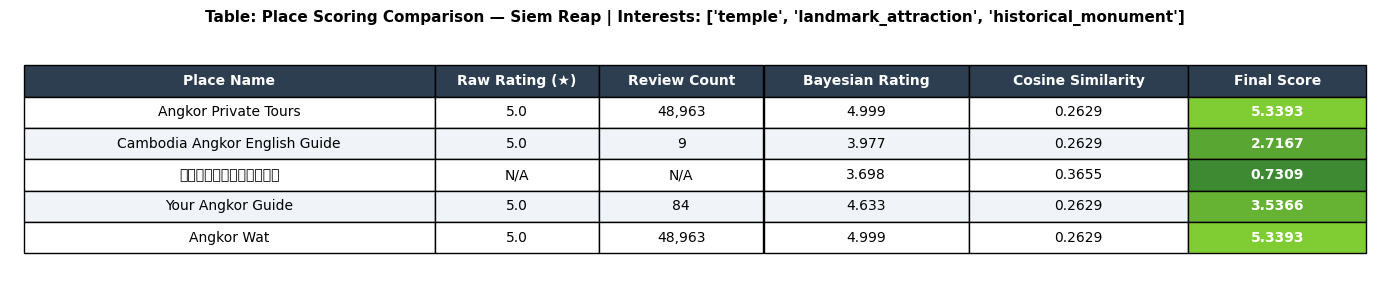

Saved → scoring_table.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')

col_widths = [0.30, 0.12, 0.12, 0.15, 0.16, 0.13]

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center',
    colWidths=col_widths,
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# Header style
for col in range(len(display_df.columns)):
    cell = table[0, col]
    cell.set_facecolor('#2c3e50')
    cell.set_text_props(color='white', fontweight='bold')

# Alternating row colors
for row in range(1, len(display_df) + 1):
    for col in range(len(display_df.columns)):
        cell = table[row, col]
        cell.set_facecolor('#f0f4f8' if row % 2 == 0 else 'white')

# Highlight the Final Score column
for row in range(1, len(display_df) + 1):
    cell = table[row, 5]
    val = float(display_df.iloc[row - 1]['Final Score'])
    max_val = max(float(v) for v in display_df['Final Score'])
    intensity = val / max_val if max_val > 0 else 0
    cell.set_facecolor(mcolors.to_hex((0.2 + intensity * 0.3, 0.5 + intensity * 0.3, 0.2)))
    cell.set_text_props(color='white', fontweight='bold')

plt.title(
    f'Table: Place Scoring Comparison — {PROVINCE} | Interests: {USER_INTERESTS}',
    fontsize=11, fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig('scoring_table.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved → scoring_table.png')

## Step 6 — Explanation annotations for each row
Print a plain-English note for each place to help write the thesis caption.

In [10]:
raw_sample = sample[['title', 'raw_rating', 'review_count',
                      'bayesian_rating', 'cat_sim', 'weighted_score', 'final_score']].copy()

print('=== Per-row annotation (use for thesis table caption) ===\n')
for i, row in raw_sample.iterrows():
    name     = row['title']
    raw_r    = f"{row['raw_rating']:.1f}" if pd.notna(row['raw_rating']) else 'N/A'
    rev      = f"{int(row['review_count']):,}" if pd.notna(row['review_count']) else 'N/A'
    bay      = row['bayesian_rating']
    sim      = row['cat_sim']
    fs       = row['final_score']

    # Generate automatic annotation
    notes = []
    if pd.isna(row['raw_rating']):
        notes.append(f'no raw rating → Bayesian falls back to dataset mean ({RATING_MEAN:.2f})')
    elif pd.notna(row['review_count']) and row['review_count'] > REVIEWS_MEDIAN * 2:
        notes.append(f'high review volume ({int(row["review_count"]):,}) → Bayesian stays close to raw rating')
    elif pd.notna(row['review_count']) and row['review_count'] < REVIEWS_MEDIAN * 0.3:
        notes.append(f'very few reviews ({int(row["review_count"])} vs median {REVIEWS_MEDIAN:.0f}) → Bayesian pulls toward mean')

    if sim > 0.3:
        notes.append(f'high cosine similarity ({sim:.4f}) → strong category match to user interests')
    elif sim < 0.05:
        notes.append(f'low cosine similarity ({sim:.4f}) → category is peripheral to user interests')

    print(f'[{name}]')
    print(f'  Raw rating: {raw_r} | Reviews: {rev} | Bayesian: {bay:.3f} | Sim: {sim:.4f} | Final: {fs:.4f}')
    for note in notes:
        print(f'  → {note}')
    print()

=== Per-row annotation (use for thesis table caption) ===

[Angkor Private Tours]
  Raw rating: 5.0 | Reviews: 48,963 | Bayesian: 4.999 | Sim: 0.2629 | Final: 5.3393
  → high review volume (48,963) → Bayesian stays close to raw rating

[Cambodia Angkor English Guide]
  Raw rating: 5.0 | Reviews: 9 | Bayesian: 3.977 | Sim: 0.2629 | Final: 2.7167
  → very few reviews (9 vs median 33) → Bayesian pulls toward mean

[ប្រាសាទបាពួន]
  Raw rating: N/A | Reviews: N/A | Bayesian: 3.698 | Sim: 0.3655 | Final: 0.7309
  → no raw rating → Bayesian falls back to dataset mean (3.70)
  → high cosine similarity (0.3655) → strong category match to user interests

[Your Angkor Guide]
  Raw rating: 5.0 | Reviews: 84 | Bayesian: 4.633 | Sim: 0.2629 | Final: 3.5366
  → high review volume (84) → Bayesian stays close to raw rating

[Angkor Wat]
  Raw rating: 5.0 | Reviews: 48,963 | Bayesian: 4.999 | Sim: 0.2629 | Final: 5.3393
  → high review volume (48,963) → Bayesian stays close to raw rating



## Step 7 — Export to CSV (optional, for pasting into Word/LaTeX)

In [11]:
display_df.to_csv('scoring_table.csv', index=True)
print('Saved → scoring_table.csv')
print('\nRaw CSV content:')
print(display_df.to_csv())

Saved → scoring_table.csv

Raw CSV content:
,Place Name,Raw Rating (★),Review Count,Bayesian Rating,Cosine Similarity,Final Score
1,Angkor Private Tours,5.0,"48,963",4.999,0.2629,5.3393
2,Cambodia Angkor English Guide,5.0,9,3.977,0.2629,2.7167
3,ប្រាសាទបាពួន,N/A,N/A,3.698,0.3655,0.7309
4,Your Angkor Guide,5.0,84,4.633,0.2629,3.5366
5,Angkor Wat,5.0,"48,963",4.999,0.2629,5.3393

